<a href="{{ colab_base_laboratorios }}/Laboratorio_03_intuicion_estadistica_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Lab 3: Intuición estadística


## Intuición estadística: modelos de *machine learning*

1. Generar dos distribuciones de probabilidad centradas en 5.0, 7.5 con desviación estándar de 2.5 y 1.5 respectivamente. Realizar un gráfico de ambas distribuciones de probabilidad.

  a). Emplear el objeto [stats.norm](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html) y el método *Probability density function* (pdf)

  b) Realizar un gráfico de ambas distribuciones

2. ¿Qué frontera analítica puede separar los datos? Determine una expresión analítica en este caso.

## Modelo de *machine learning*

3. Empleando el método *Random variates* (rvs), genere 100 muestras aleatorias para cada distribución; estos serán los datos de entrenamiento.

4. Realice un gráfico en el que pueda superponer ambas distribuciones; estas 200 muestras serán las características (*features*) de nuestro data frame. Para cada característica tendremos una etiqueta (*labels*) correspondiente a 0 ó 1.

5. Con los datos anteriores construya un `DataFrame` con los *features* y *labels* de la siguiente forma:

 |Y (*labels*)| X_1 (*feature*)|
 |---|---|
 |$Y^{1}$| $X_1^{1}$|
 |$Y^{2}$| $X_1^{2}$|
 |.| .|
 |.| .|
 |.| .|
 |$Y^{m}$| $X_1^{m}$|

- Se sugiere emplear las claves `Y`, `X` para los labels y features respectivamente.
- $Y^{1}, Y^{2}, ... , Y^{m}$ son los labels de entrenamiento.
- $X_1^{1}, X_1^{2}, ... , X_1^{m}$ es el conjunto de datos de entrenamiento asociado a la característica 1 en el entrenamiento m.
- Este dataframe será el dataset de entrenamiento; para los datos de test construiremos 50 variables aleatorias.

6. Construye un segundo data frame con 50 datos de test, asociados a las muestras de las dos distribuciones; estos serán los datos de test empleados para validar los algoritmos de clasificación `df_test` con claves `Y`, `X_1`.

## Modelo de *machine learning* (clasificación)

7. Por ahora, emplearemos clasificadores bajo un modelo de caja negra. La forma para implementar el modelo es la siguiente:

  - Definir el modelo y realizar el `fit`:

  ```
  clf = LinearRegression()
  clf.fit(X_train, Y_train)
  ```

  - Determinar el `score` de los datos de entrenamiento:

  ```
  score = clf.score(X_train, Y_train)
  ```

  - Determinar el `score` para los datos de test. ¿Qué puede concluir mirando los scores?

  Nota:
  Emplear los siguientes clasificadores de machine learning y determinar los scores para cada modelo.

  ```
  - DecisionTreeClassifier(max_depth=3)
  - SVC(kernel="linear", C=0.025)
  ```

8. Existen librerías que pueden optimizar los hyperparámetros de cualquier modelo: [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html). Prueba a implementar las siguientes líneas de código con el siguiente modelo:

```
from sklearn.model_selection import GridSearchCV

  param_grid = {
    'max_depth' : [3,4,5,6,7,8],
    'criterion' :['gini', 'entropy']
}

  CV_clf = GridSearchCV(estimator=clf, param_grid=param_grid, cv= 10)
  CV_clf.fit(x_train, y_train)
```

9. En los algoritmos de *machining learning* es de suma importancia conocer las curvas de aprendizaje para decidir si el algoritmo funciona de manera optima, emplea las siguiente lineas de código para mostrar las curvas de aprendizaje de la regresion lineal. 

```
title = "Learning Curves"
plot_learning_curve(
    regr, title, Xtr_, ytr_,  ylim=(0.5, 1.01),  n_jobs=4
)
```


10. Pruea a construir curvas de aprendizaje para los siguientes valores en las distribuciones(emplea una regresion lineal):
  - Datos de entrenamiento 30. media1=7.5, media2=10, desv1=1, desv1=1
  - Datos de entrenamiento 100. media1=7.5, media2=10, desv1=1, desv1=1
  - Datos de entrenamiento 200. media1=7.5, media2=7.0, desv1 = 2, desv1 = 2  
  - Datos de entrenamiento 200. media1=7.5, media2=7.0, desv1 = 0.5, desv1 = 0.5  
  -¿Qué puede concluir? de cada prueba.


Nota: Busca siempre la manera de construir tus codigos de forma estructurada  de tal forma que puedar variar parametros con facilidad.




In [1]:
#import sklearn
#import numpy as np
#import pandas as pd
#import matplotlib.pylab as plt
#import seaborn as sns
#from scipy import stats
#from scipy import optimize
#from scipy.stats import norm


In [2]:
# 1. Construir dos distribuciones 
#x = np.linspace(5, 30,100)
#mean1 = 8
#desv1 = 0.1
#f1 = stats.norm(loc = mean1, scale = desv1)


In [3]:
#plt.plot(x,f1.pdf(x))

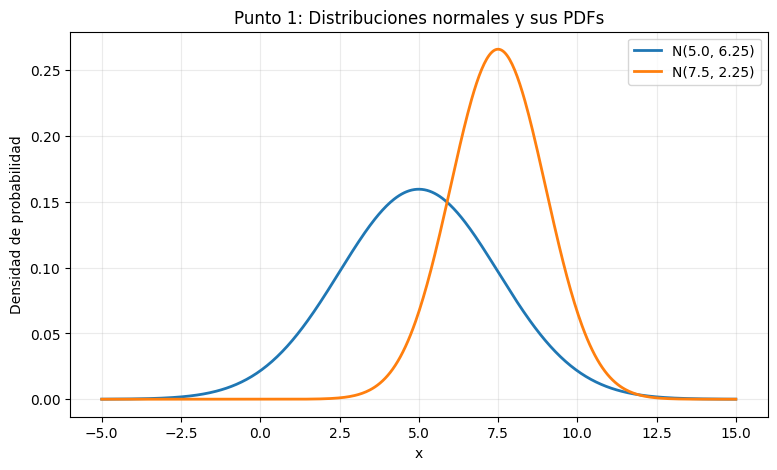

Distribucion 1: media = 5.0 , desviacion estandar = 2.5
Distribucion 2: media = 7.5 , desviacion estandar = 1.5


In [1]:
# Punto 1: dos distribuciones normales y su grafico de densidad (PDF)
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Parametros solicitados en el enunciado
mu1, sigma1 = 5.0, 2.5
mu2, sigma2 = 7.5, 1.5

# Objetos de distribucion normal usando scipy.stats.norm
dist1 = stats.norm(loc=mu1, scale=sigma1)
dist2 = stats.norm(loc=mu2, scale=sigma2)

# Rango de x que cubre bien ambas campanas (aprox. +/- 4 sigmas)
x_min = min(mu1 - 4 * sigma1, mu2 - 4 * sigma2)
x_max = max(mu1 + 4 * sigma1, mu2 + 4 * sigma2)
x = np.linspace(x_min, x_max, 500)

# PDFs
pdf1 = dist1.pdf(x)
pdf2 = dist2.pdf(x)

# Grafico de ambas distribuciones
plt.figure(figsize=(9, 5))
plt.plot(x, pdf1, label=f'N({mu1}, {sigma1**2})', linewidth=2)
plt.plot(x, pdf2, label=f'N({mu2}, {sigma2**2})', linewidth=2)
plt.title('Punto 1: Distribuciones normales y sus PDFs')
plt.xlabel('x')
plt.ylabel('Densidad de probabilidad')
plt.grid(alpha=0.25)
plt.legend()
plt.show()

print('Distribucion 1: media =', mu1, ', desviacion estandar =', sigma1)
print('Distribucion 2: media =', mu2, ', desviacion estandar =', sigma2)

## Punto 2: frontera analítica de separación

Con tu corrección, buscamos $X \in (-\infty,\infty)$ tal que
$$
\frac{\int_{-\infty}^{X} f_1(x)\,dx}{\int_{X}^{\infty} f_2(x)\,dx}=1
\quad\Longleftrightarrow\quad
\int_{-\infty}^{X} f_1(x)\,dx = \int_{X}^{\infty} f_2(x)\,dx.
$$

Usando funciones de distribución acumulada (CDF):
$$
F_1(X) = 1 - F_2(X)
\quad\Longleftrightarrow\quad
F_1(X)+F_2(X)=1.
$$

Este criterio **sí es viable** y define un umbral balanceado entre "masa acumulada a la izquierda" de la clase 1 y "cola derecha" de la clase 2.

Nota: este umbral no necesariamente coincide con la frontera Bayes ($f_1(X)=f_2(X)$), pero es una frontera analítica válida según el criterio que propusiste.

X por tu criterio (F1(X) + F2(X) = 1): 6.5625
Chequeo razon = F1(X)/(1-F2(X)): 1.0000
Frontera Bayes principal (f1=f2): 5.8921


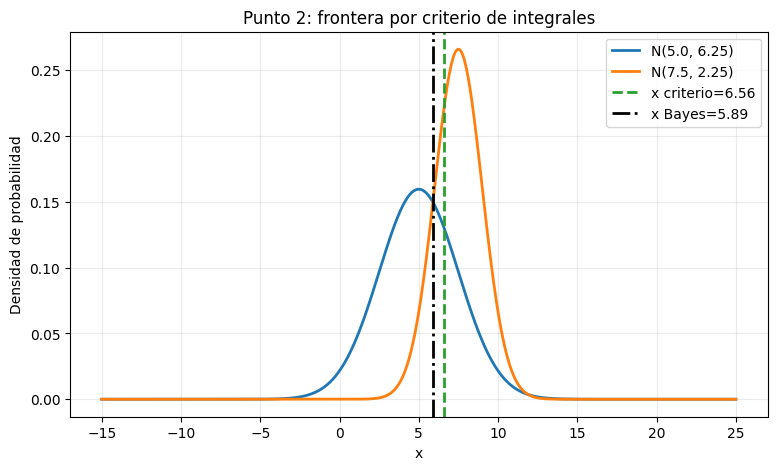

In [4]:
# Punto 2 con tu criterio corregido:
# encontrar X tal que int_{-inf}^{X} f1 = int_{X}^{inf} f2

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, optimize

# Parametros del problema
mu1, sigma1 = 5.0, 2.5
mu2, sigma2 = 7.5, 1.5

dist1 = stats.norm(loc=mu1, scale=sigma1)
dist2 = stats.norm(loc=mu2, scale=sigma2)

# Ecuacion equivalente: F1(X) + F2(X) - 1 = 0
def g(x):
    return dist1.cdf(x) + dist2.cdf(x) - 1.0

# Busqueda de raiz en un intervalo amplio
x_left = min(mu1 - 8 * sigma1, mu2 - 8 * sigma2)
x_right = max(mu1 + 8 * sigma1, mu2 + 8 * sigma2)

x_criterio = optimize.brentq(g, x_left, x_right)

# Para comparar, frontera Bayes con priors iguales: f1(x) = f2(x)
a = 1.0 / (2 * sigma1**2) - 1.0 / (2 * sigma2**2)
b = -mu1 / (sigma1**2) + mu2 / (sigma2**2)
c = (mu1**2) / (2 * sigma1**2) - (mu2**2) / (2 * sigma2**2) + np.log(sigma1 / sigma2)

roots = np.roots([a, b, c])
roots = np.sort(np.real(roots[np.isreal(roots)]))

candidatos = roots[(roots > min(mu1, mu2)) & (roots < max(mu1, mu2))]
if len(candidatos) > 0:
    x_bayes = float(candidatos[0])
else:
    x_bayes = float(roots[np.argmin(np.abs(roots - (mu1 + mu2) / 2))])

print(f"X por tu criterio (F1(X) + F2(X) = 1): {x_criterio:.4f}")
print(f"Chequeo razon = F1(X)/(1-F2(X)): {dist1.cdf(x_criterio)/(1-dist2.cdf(x_criterio)):.4f}")
print(f"Frontera Bayes principal (f1=f2): {x_bayes:.4f}")

# Grafica
x = np.linspace(x_left, x_right, 700)
plt.figure(figsize=(9, 5))
plt.plot(x, dist1.pdf(x), label=f'N({mu1}, {sigma1**2})', linewidth=2)
plt.plot(x, dist2.pdf(x), label=f'N({mu2}, {sigma2**2})', linewidth=2)
plt.axvline(x_criterio, color='tab:green', linestyle='--', linewidth=2, label=f'x criterio={x_criterio:.2f}')
plt.axvline(x_bayes, color='black', linestyle='-.', linewidth=2, label=f'x Bayes={x_bayes:.2f}')
plt.title('Punto 2: frontera por criterio de integrales')
plt.xlabel('x')
plt.ylabel('Densidad de probabilidad')
plt.grid(alpha=0.25)
plt.legend()
plt.show()

## Configuración para puntos 3 a 10

Este bloque define librerías y funciones auxiliares.

Después, cada punto (3 al 10) se resuelve en su propia pareja de celdas: una markdown de contexto y una de código.

In [3]:
# Configuracion base para puntos 3 a 10

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, learning_curve

# ------------------------------------------------------------------
# Utilidades
# ------------------------------------------------------------------

def generar_datos_normales(mu1, sigma1, mu2, sigma2, n_train_por_clase=100, n_test_total=50, seed=42):
    """Genera train y test para dos clases normales unidimensionales."""
    rng = np.random.default_rng(seed)

    # Train (punto 3): n_train_por_clase por cada distribucion
    x0_train = rng.normal(mu1, sigma1, n_train_por_clase)
    x1_train = rng.normal(mu2, sigma2, n_train_por_clase)

    y0_train = np.zeros(n_train_por_clase, dtype=int)
    y1_train = np.ones(n_train_por_clase, dtype=int)

    x_train = np.concatenate([x0_train, x1_train])
    y_train = np.concatenate([y0_train, y1_train])

    # Test (punto 6): total 50 -> 25 por clase
    n_test_c0 = n_test_total // 2
    n_test_c1 = n_test_total - n_test_c0

    x0_test = rng.normal(mu1, sigma1, n_test_c0)
    x1_test = rng.normal(mu2, sigma2, n_test_c1)

    y0_test = np.zeros(n_test_c0, dtype=int)
    y1_test = np.ones(n_test_c1, dtype=int)

    x_test = np.concatenate([x0_test, x1_test])
    y_test = np.concatenate([y0_test, y1_test])

    # DataFrames (puntos 5 y 6)
    df_train = pd.DataFrame({"Y": y_train, "X_1": x_train})
    df_test = pd.DataFrame({"Y": y_test, "X_1": x_test})

    return df_train, df_test


def graficar_densidades_y_muestras(mu1, sigma1, mu2, sigma2, df_train):
    """Punto 4: superponer densidades teoricas y muestras de entrenamiento."""
    dist1 = stats.norm(loc=mu1, scale=sigma1)
    dist2 = stats.norm(loc=mu2, scale=sigma2)

    xmin = min(mu1 - 5 * sigma1, mu2 - 5 * sigma2)
    xmax = max(mu1 + 5 * sigma1, mu2 + 5 * sigma2)
    x = np.linspace(xmin, xmax, 600)

    plt.figure(figsize=(10, 5))
    plt.plot(x, dist1.pdf(x), label=f"PDF clase 0: N({mu1}, {sigma1**2})", linewidth=2)
    plt.plot(x, dist2.pdf(x), label=f"PDF clase 1: N({mu2}, {sigma2**2})", linewidth=2)

    x0 = df_train.loc[df_train["Y"] == 0, "X_1"].to_numpy()
    x1 = df_train.loc[df_train["Y"] == 1, "X_1"].to_numpy()

    # Muestras como puntos en y=0 para visualizar features por clase
    plt.scatter(x0, np.zeros_like(x0), s=18, alpha=0.6, label="Muestras train clase 0")
    plt.scatter(x1, np.zeros_like(x1), s=18, alpha=0.6, label="Muestras train clase 1")

    plt.title("Punto 4: distribuciones y muestras de entrenamiento")
    plt.xlabel("X_1")
    plt.ylabel("Densidad")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.show()


def evaluar_modelos(df_train, df_test):
    """Punto 7: ajusta modelos y reporta scores train/test."""
    X_train = df_train[["X_1"]].to_numpy()
    y_train = df_train["Y"].to_numpy()
    X_test = df_test[["X_1"]].to_numpy()
    y_test = df_test["Y"].to_numpy()

    # LinearRegression (score = R^2)
    regr = LinearRegression()
    regr.fit(X_train, y_train)
    regr_train_score = regr.score(X_train, y_train)
    regr_test_score = regr.score(X_test, y_test)

    # Para comparar en clasificacion, umbral 0.5
    yhat_train_cls = (regr.predict(X_train) >= 0.5).astype(int)
    yhat_test_cls = (regr.predict(X_test) >= 0.5).astype(int)
    regr_train_acc = (yhat_train_cls == y_train).mean()
    regr_test_acc = (yhat_test_cls == y_test).mean()

    # DecisionTreeClassifier
    tree = DecisionTreeClassifier(max_depth=3, random_state=42)
    tree.fit(X_train, y_train)
    tree_train_score = tree.score(X_train, y_train)
    tree_test_score = tree.score(X_test, y_test)

    # SVC lineal
    svc = SVC(kernel="linear", C=0.025, random_state=42)
    svc.fit(X_train, y_train)
    svc_train_score = svc.score(X_train, y_train)
    svc_test_score = svc.score(X_test, y_test)

    resultados = pd.DataFrame(
        {
            "modelo": ["LinearRegression (R2)", "LinearRegression (acc)", "DecisionTreeClassifier", "SVC linear"],
            "score_train": [regr_train_score, regr_train_acc, tree_train_score, svc_train_score],
            "score_test": [regr_test_score, regr_test_acc, tree_test_score, svc_test_score],
        }
    )

    return resultados, regr, tree, svc


def plot_learning_curve_simple(estimator, X, y, title, scoring, ylabel, ax=None):
    """Puntos 9 y 10: curva de aprendizaje generica."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 4))

    train_sizes, train_scores, val_scores = learning_curve(
        estimator,
        X,
        y,
        cv=5,
        n_jobs=-1,
        train_sizes=np.linspace(0.2, 1.0, 5),
        scoring=scoring,
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, marker="o", label="Train")
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)

    ax.plot(train_sizes, val_mean, marker="s", label="Validation")
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15)

    ax.set_title(title)
    ax.set_xlabel("Numero de muestras de entrenamiento")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)
    ax.legend()

    return train_sizes, train_mean, val_mean

### Punto 3: generación de muestras de entrenamiento

Generamos 100 muestras por clase usando distribuciones normales.

Además definimos parámetros globales que se reutilizan en los siguientes puntos.

In [4]:
# Punto 3: 100 muestras por distribucion para entrenamiento
mu1, sigma1 = 5.0, 2.5
mu2, sigma2 = 7.5, 1.5

df_train, df_test = generar_datos_normales(
    mu1=mu1,
    sigma1=sigma1,
    mu2=mu2,
    sigma2=sigma2,
    n_train_por_clase=100,
    n_test_total=50,
    seed=42,
)

print("Punto 3: muestras generadas")
print("Tamano df_train:", df_train.shape)
print("Tamano df_test:", df_test.shape)

Punto 3: muestras generadas
Tamano df_train: (200, 2)
Tamano df_test: (50, 2)


### Punto 4: visualización de distribuciones y muestras

Se superponen las densidades teóricas con las muestras de entrenamiento para inspección visual de separabilidad.

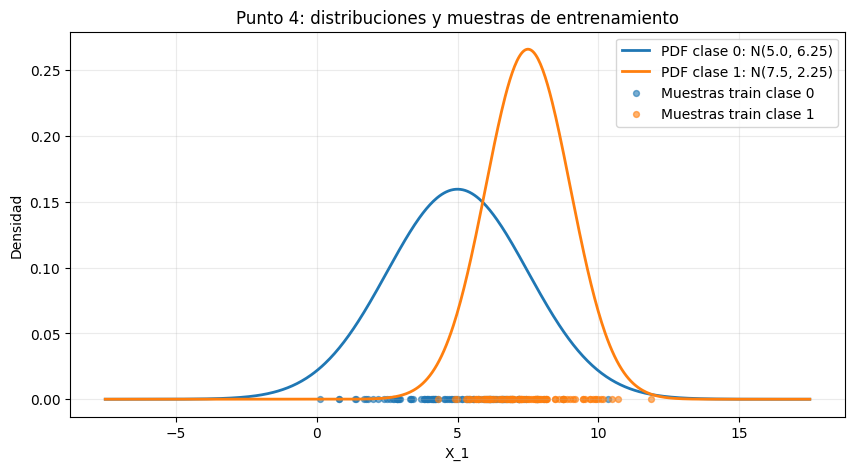

In [5]:
# Punto 4: grafico de distribuciones + muestras
graficar_densidades_y_muestras(mu1, sigma1, mu2, sigma2, df_train)

### Punto 5: construir df_train

Aquí se muestra el DataFrame de entrenamiento con columnas `Y` (label) y `X_1` (feature).

In [6]:
# Punto 5: mostrar dataframe de entrenamiento
print("Punto 5: df_train (primeras 5 filas)")
display(df_train.head())

Punto 5: df_train (primeras 5 filas)


,Y,X_1
0,0,5.761793
1,0,2.400040
2,0,6.876128
3,0,7.351412
4,0,0.122412


### Punto 6: construir df_test

Ahora mostramos el conjunto de prueba con 50 observaciones y la misma estructura (`Y`, `X_1`).

In [7]:
# Punto 6: mostrar dataframe de test
print("Punto 6: df_test (primeras 5 filas)")
display(df_test.head())

Punto 6: df_test (primeras 5 filas)


,Y,X_1
0,0,5.843936
1,0,8.518705
2,0,5.226462
3,0,6.609847
4,0,-0.125430


### Punto 7: entrenamiento de modelos y scores

Se comparan tres modelos: `LinearRegression`, `DecisionTreeClassifier(max_depth=3)` y `SVC(kernel="linear", C=0.025)`.

Sobre $R^2$:

$R^2$ mide la fracción de variabilidad de $Y$ explicada por el modelo lineal.

$$
R^2 = 1 - \frac{\sum_i (y_i-\hat y_i)^2}{\sum_i (y_i-\bar y)^2}
$$

Interpretación:
- $R^2\approx 1$: el modelo explica muy bien los datos.
- $R^2\approx 0$: el modelo no mejora frente a predecir la media.
- $R^2<0$: peor que predecir siempre la media.

Para evidenciar aprendizaje, se compara `score_train` vs `score_test`:
- brecha grande: posible sobreajuste,
- ambos bajos: posible subajuste,
- cercanos y razonables: mejor generalización.

In [8]:
# Punto 7: modelos y scores
resultados, regr, tree, svc = evaluar_modelos(df_train, df_test)
print("Punto 7: scores de entrenamiento y test")
display(resultados)

print("Conclusion breve punto 7:")
print("- Si score_train >> score_test, hay sobreajuste.")
print("- Si ambos son bajos, hay subajuste.")
print("- Compara los tres modelos segun score_test para elegir mejor generalizacion.")

Punto 7: scores de entrenamiento y test


,modelo,score_train,score_test
0,LinearRegression (R2),0.367153,0.251809
1,LinearRegression (acc),0.740000,0.720000
2,DecisionTreeClassifier,0.780000,0.740000
3,SVC linear,0.745000,0.720000


Conclusion breve punto 7:
- Si score_train >> score_test, hay sobreajuste.
- Si ambos son bajos, hay subajuste.
- Compara los tres modelos segun score_test para elegir mejor generalizacion.


### Punto 8: optimización de hiperparámetros con GridSearchCV

Se usa búsqueda en rejilla para `DecisionTreeClassifier` con:
- `max_depth` en `[3,4,5,6,7,8]`
- `criterion` en `['gini', 'entropy']`

Luego se reporta el mejor modelo y su desempeño en test.

In [9]:
# Punto 8: GridSearchCV para DecisionTreeClassifier
X_train = df_train[["X_1"]].to_numpy()
y_train = df_train["Y"].to_numpy()
X_test = df_test[["X_1"]].to_numpy()
y_test = df_test["Y"].to_numpy()

clf_base = DecisionTreeClassifier(random_state=42)
param_grid = {
    "max_depth": [3, 4, 5, 6, 7, 8],
    "criterion": ["gini", "entropy"],
}

cv_clf = GridSearchCV(estimator=clf_base, param_grid=param_grid, cv=10, n_jobs=-1)
cv_clf.fit(X_train, y_train)

print("Punto 8: GridSearchCV")
print("Mejores hiperparametros:", cv_clf.best_params_)
print(f"Mejor score CV: {cv_clf.best_score_:.4f}")
print(f"Score test del mejor modelo: {cv_clf.best_estimator_.score(X_test, y_test):.4f}")

Punto 8: GridSearchCV
Mejores hiperparametros: {'criterion': 'entropy', 'max_depth': 4}
Mejor score CV: 0.7150
Score test del mejor modelo: 0.6600


### Punto 9: curva de aprendizaje con regresión lineal

En esta parte se usa `LinearRegression` y se grafica el aprendizaje con métrica $R^2$.

¿Cómo da cuenta $R^2$ del aprendizaje?
- Si al aumentar muestras el $R^2$ de validación sube y se estabiliza, el modelo está aprendiendo patrones que generalizan.
- Si $R^2$ de train es alto pero validación bajo, el modelo memoriza (sobreajuste).
- Si ambos $R^2$ son bajos, la relación lineal entre `X_1` y `Y` es débil o el modelo es insuficiente.

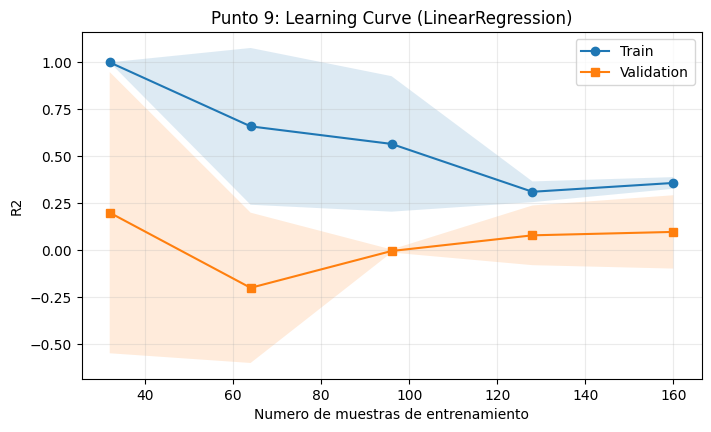

In [10]:
# Punto 9: curva de aprendizaje para regresion lineal
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_learning_curve_simple(
    LinearRegression(),
    X_train,
    y_train,
    "Punto 9: Learning Curve (LinearRegression)",
    scoring="r2",
    ylabel="R2",
    ax=ax,
)
plt.show()

### Punto 10: curvas de aprendizaje en escenarios propuestos

Se repite el análisis con `LinearRegression` para cuatro escenarios de medias, desviaciones y tamaño de entrenamiento.

Al final se resume el último valor de train/validación para comparar capacidad de aprendizaje y generalización entre escenarios.

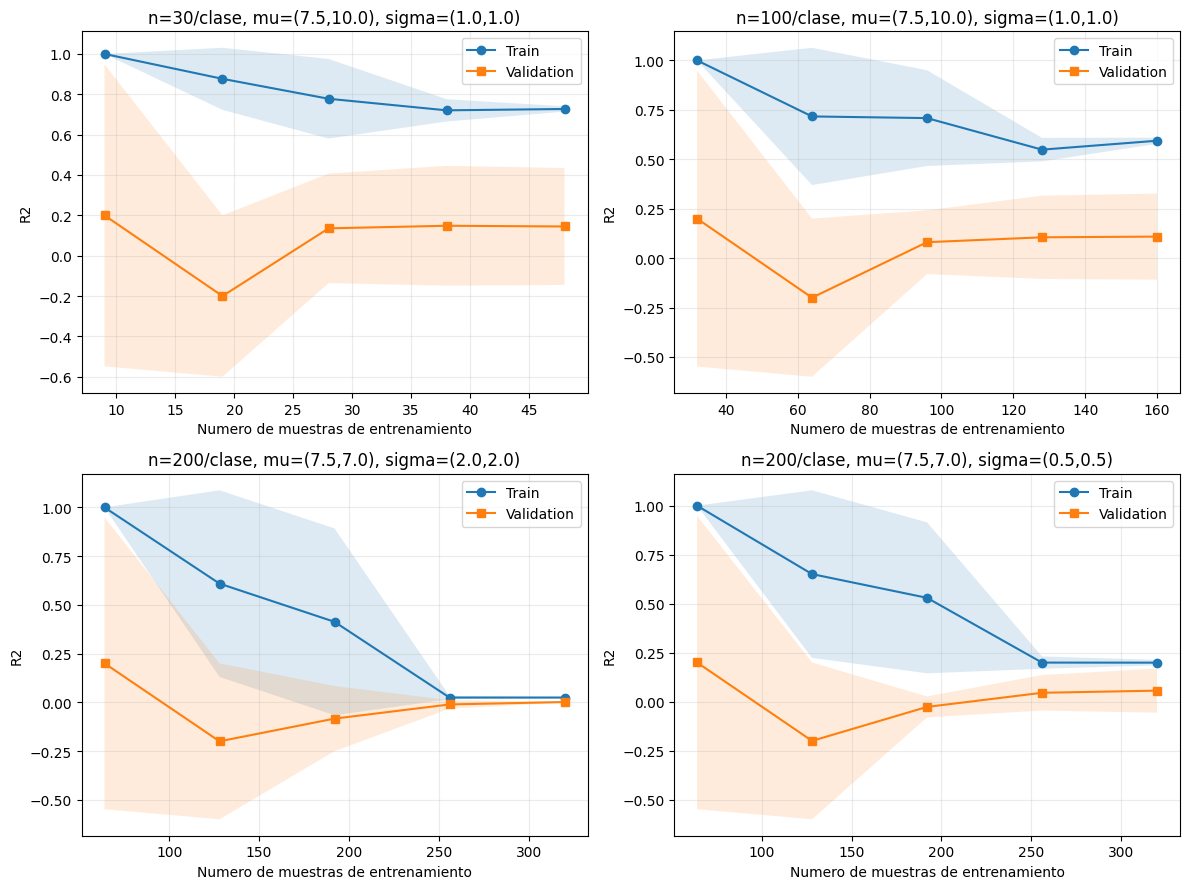

Punto 10: resumen numerico de escenarios (ultimo punto de la curva)


,escenario,n_train_por_clase,mu1,mu2,sigma1,sigma2,train_final,val_final,gap_final
0,1,30,7.5,10.0,1.0,1.0,0.727088,0.144860,0.582228
1,2,100,7.5,10.0,1.0,1.0,0.593643,0.108895,0.484748
2,3,200,7.5,7.0,2.0,2.0,0.024446,0.001446,0.023000
3,4,200,7.5,7.0,0.5,0.5,0.199041,0.056255,0.142785


Conclusiones sugeridas del punto 10:
- Mas datos tienden a estabilizar la curva y reducir varianza.
- Si las medias estan muy cerca y las desviaciones son altas, el R2 cae por menor separabilidad.
- Si las desviaciones son bajas, la estructura lineal entre X_1 y Y es mas clara y mejora el R2.


In [11]:
# Punto 10: curvas de aprendizaje con regresion lineal en escenarios
escenarios = [
    {"n_train": 30, "mu1": 7.5, "mu2": 10.0, "sigma1": 1.0, "sigma2": 1.0},
    {"n_train": 100, "mu1": 7.5, "mu2": 10.0, "sigma1": 1.0, "sigma2": 1.0},
    {"n_train": 200, "mu1": 7.5, "mu2": 7.0, "sigma1": 2.0, "sigma2": 2.0},
    {"n_train": 200, "mu1": 7.5, "mu2": 7.0, "sigma1": 0.5, "sigma2": 0.5},
]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.ravel()

resumen_escenarios = []

for i, esc in enumerate(escenarios):
    df_tr_i, _ = generar_datos_normales(
        mu1=esc["mu1"],
        sigma1=esc["sigma1"],
        mu2=esc["mu2"],
        sigma2=esc["sigma2"],
        n_train_por_clase=esc["n_train"],
        n_test_total=50,
        seed=42 + i,
    )

    X_tr_i = df_tr_i[["X_1"]].to_numpy()
    y_tr_i = df_tr_i["Y"].to_numpy()

    title_i = (
        f"n={esc['n_train']}/clase, mu=({esc['mu1']},{esc['mu2']}), "
        f"sigma=({esc['sigma1']},{esc['sigma2']})"
    )

    _, train_mean_i, val_mean_i = plot_learning_curve_simple(
        LinearRegression(),
        X_tr_i,
        y_tr_i,
        title_i,
        scoring="r2",
        ylabel="R2",
        ax=axes[i],
    )

    resumen_escenarios.append(
        {
            "escenario": i + 1,
            "n_train_por_clase": esc["n_train"],
            "mu1": esc["mu1"],
            "mu2": esc["mu2"],
            "sigma1": esc["sigma1"],
            "sigma2": esc["sigma2"],
            "train_final": train_mean_i[-1],
            "val_final": val_mean_i[-1],
            "gap_final": train_mean_i[-1] - val_mean_i[-1],
        }
    )

plt.tight_layout()
plt.show()

resumen_df = pd.DataFrame(resumen_escenarios)
print("Punto 10: resumen numerico de escenarios (ultimo punto de la curva)")
display(resumen_df)

print("Conclusiones sugeridas del punto 10:")
print("- Mas datos tienden a estabilizar la curva y reducir varianza.")
print("- Si las medias estan muy cerca y las desviaciones son altas, el R2 cae por menor separabilidad.")
print("- Si las desviaciones son bajas, la estructura lineal entre X_1 y Y es mas clara y mejora el R2.")